# Development of Consistent Prediction

Develop useful consistency metrics

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import robomimic.dev.hparam.utils.demo_utils as demo_utils
import robomimic.dev.hparam.utils.pkl_utils as pkl_utils
import robomimic.dev.hparam.utils.stat_utils as stat_utils
import robomimic.dev.hparam.utils.plot_utils as plot_utils

import robomimic.dev.hparam.metrics.metric_fn as Metrics
from robomimic.dev.hparam.eval_suite import DemoEvalSuite


In [2]:
result_dir  = "/home/wjung85/Repo/projects/FastIL/logs/hparam_debug"
result_idx  = 0 
demo_idx    = 0

In [3]:
baseline_pkls = pkl_utils.get_result_pkl_files(result_dir, filter="bl")
inpaint_pkls  = pkl_utils.get_result_pkl_files(result_dir, filter="inp")
result_grp = pkl_utils.load_result_pkl_file(baseline_pkls[result_idx])
demo_grp  = result_grp["rollouts"][f"demo_{demo_idx}"]

result_grp = pkl_utils.load_result_pkl_file(inpaint_pkls[result_idx])
demo_inp  = result_grp["rollouts"][f"demo_{demo_idx}"]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


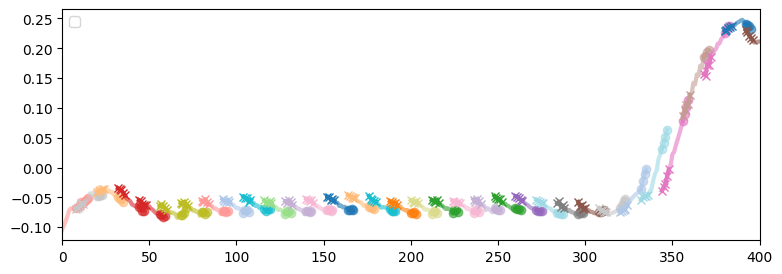

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


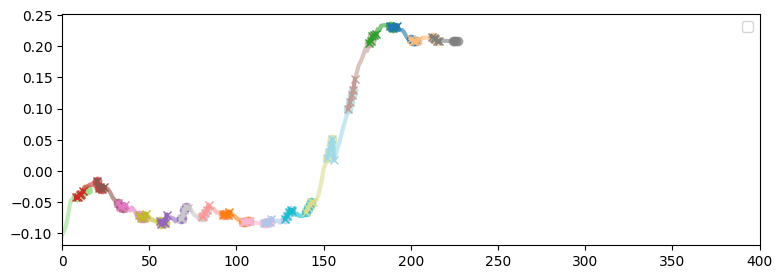

In [4]:
_ = plot_utils.plot_predictions(demo_grp, action_idx=0, xlim=(0, 400))
_ = plot_utils.plot_predictions(demo_inp, action_idx=0, xlim=(0, 400))

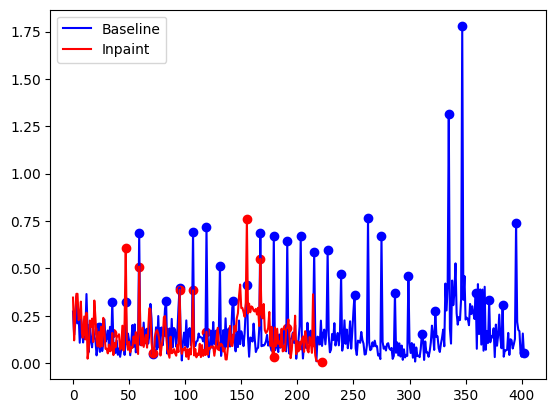

In [5]:
# Showing that the peak is at the knot (i*Ta-1)
velocity = demo_utils.get_end_effector_velocity(demo_grp, type="cmd")
speed = np.linalg.norm(velocity, axis=-1)
velocity_inp = demo_utils.get_end_effector_velocity(demo_inp, type="cmd")
speed_inp = np.linalg.norm(velocity_inp, axis=-1)

timestamps = demo_utils.get_timestamps(demo_grp)
timestamps_inp = demo_utils.get_timestamps(demo_inp)
knot_timestamps = demo_utils.get_knot_timestamps(demo_grp)
knot_timestamps_inp = demo_utils.get_knot_timestamps(demo_inp)
plt.plot(timestamps[:-1], speed, color="blue")
plt.plot(timestamps_inp[:-1], speed_inp, color="red")
plt.scatter(knot_timestamps, speed[knot_timestamps], color="blue", marker="o")
plt.scatter(knot_timestamps_inp, speed_inp[knot_timestamps_inp], color="red", marker="o")
plt.legend(["Baseline", "Inpaint"])
plt.show()



In [7]:
def switch_delta_eval_fn(demo):
    """
    Evaluate the action delta at the "knot" of the trajectory
    """
    Ta = demo_utils.get_Ta(demo)
    knot_timestamps = demo_utils.get_knot_timestamps(demo)
    
    actions = np.array(demo["executed_actions"])

    delta_actions = np.diff(actions, axis=0)
    
    # Remove the gripper action
    delta_actions = delta_actions[:, :-1]
    
    speed = np.linalg.norm(delta_actions, axis=-1)

    speed_knot = speed[knot_timestamps]

    return speed_knot